In [2]:
data_isoflops = [
    [227466240, 4.46835],
    [133794048, 4.02257],
    [63919616, 3.85442],
    [43908480, 3.9474],
    [27240192, 4.32467]
]

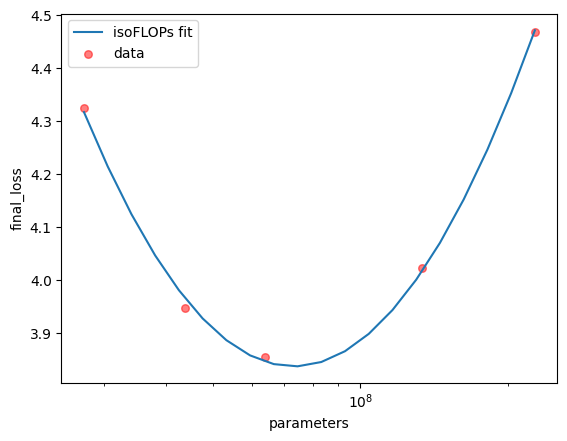

In [13]:
# Draw isoflops exp

from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np

def func(x, a, b, c):
    return a*x**2 + b*x + c

parameters = [row[0] for row in data_isoflops]
losses = [row[1] for row in data_isoflops]

parameters_log = np.log10(parameters)
popt, pcov = curve_fit(func, parameters_log, losses)

# Fitted curve
x_dense_log = np.linspace(
    parameters_log.min(),
    parameters_log.max(),
    20      # 越大越smooth
)
x_dense = 10 ** x_dense_log
plt.plot(x_dense, func(x_dense_log, *popt), label="isoFLOPs fit")

# Original curve
plt.scatter(parameters, losses, s=30, alpha=0.5, color="red", label="data")
    
plt.xscale('log')
plt.legend()
plt.xlabel("parameters")
plt.ylabel("final_loss")
plt.show()